# Delivery Time Prediction — Modelling (LightGBM)

**Input:** `train_features.csv` / `test_features.csv`  
**Model:** LightGBM with native categorical handling  
**Metric:** MAE

---
## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import warnings, os
warnings.filterwarnings('ignore')

SEED     = 42
TARGET   = 'delivery_time_days'
N_FOLDS  = 5
CAT_COLS = ['product_category_name_english', 'customer_city', 'seller_city']

print('Setup complete ✓')

/Users/anas/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Setup complete ✓


---
## 1. Load data

In [7]:
train = pd.read_csv('dataset/processed/train_features.csv')
test  = pd.read_csv('dataset/processed/test_features.csv')

train = train.drop(columns=['same_city', 'quantity', 'same_day_approval', 'is_weekend', 'approval_lag_hours'])
test = test.drop(columns=['same_city', 'quantity', 'same_day_approval', 'is_weekend', 'approval_lag_hours'])

# Restore category dtype (lost on CSV save/load)
for col in CAT_COLS:
    train[col] = train[col].astype('category')
    test[col]  = test[col].astype('category')

X      = train.drop(columns=[TARGET])
y      = train[TARGET]
X_test = test.copy()

naive_mae = mean_absolute_error(y, np.full(len(y), y.median()))

print(f'Train  : {X.shape}')
print(f'Test   : {X_test.shape}')
print(f'Naive baseline MAE : {naive_mae:.4f}')
print(f'Features : {list(X.columns)}')

Train  : (83401, 12)
Test   : (15029, 12)
Naive baseline MAE : 6.1846
Features : ['customer_city', 'seller_city', 'price', 'freight_value', 'product_weight_g', 'volume_cm3', 'product_category_name_english', 'purchase_month', 'distance_km', 'product_density', 'seller_mean_delivery', 'seller_pending_orders']


---
## 2. Cross-validation

In [ ]:
params = {
    'objective'        : 'mae',
    'metric'           : 'mae',
    'n_estimators'     : 3000,
    'learning_rate'    : 0.02,
    'num_leaves'       : 31,
    'min_child_samples': 50,
    'subsample'        : 0.7,
    'colsample_bytree' : 0.7,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 1.0,
    'random_state'     : SEED,
    'verbose'          : -1,
}

kf         = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
oof_preds  = np.zeros(len(X))
test_preds = np.zeros(len(X_test))
fold_maes  = []

for fold, (tr_idx, val_idx) in enumerate(kf.split(X), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        categorical_feature=CAT_COLS,
        callbacks=[
            lgb.early_stopping(100, verbose=False),
            lgb.log_evaluation(period=-1)
        ]
    )

    oof_preds[val_idx]  = model.predict(X_val)
    test_preds         += model.predict(X_test) / N_FOLDS

    mae = mean_absolute_error(y_val, oof_preds[val_idx])
    fold_maes.append(mae)
    print(f'Fold {fold} — MAE: {mae:.4f}  |  best iter: {model.best_iteration_}')

cv_mae = mean_absolute_error(y, oof_preds)
print(f'\nCV MAE (OOF)        : {cv_mae:.4f}')
print(f'Std across folds    : {np.std(fold_maes):.4f}')
print(f'Improvement vs naive: {naive_mae - cv_mae:.4f} days')

---
## 3. Feature importance

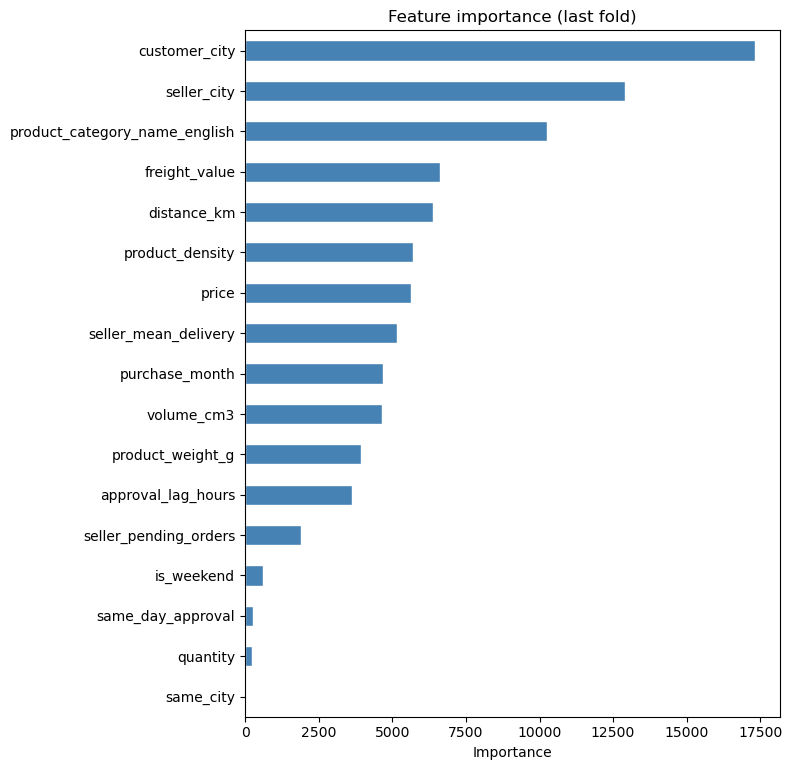

In [5]:
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, len(importance) * 0.4 + 1))
importance.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Feature importance (last fold)')
ax.set_xlabel('Importance')
plt.tight_layout()
os.makedirs('../plots', exist_ok=True)
plt.savefig('../plots/feature_importance.png', bbox_inches='tight', dpi=120)
plt.show()

---
## 4. Save submission

In [4]:
os.makedirs('submissions', exist_ok=True)

assert test_preds.max() > 0,         'Predictions are all zeros!'
assert len(test_preds) == len(test), 'Row count mismatch!'

submission = pd.DataFrame({
    'id'                : range(len(test_preds)),
    'delivery_time_days': test_preds
})

submission.to_csv('submissions/submission_lgbm_v3.csv', index=False)

print(f'Submission saved ✓  —  {len(submission):,} rows')
print(submission['delivery_time_days'].describe().round(2))

Submission saved ✓  —  15,029 rows
count    15029.00
mean         9.53
std          4.28
min          1.61
25%          6.38
50%          9.03
75%         12.09
max         34.76
Name: delivery_time_days, dtype: float64
